# Sparsity identification and information extraction for quantum states

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch, Rectangle
from matplotlib.lines import Line2D
import matplotlib.ticker as mtick
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

This notebook presents the classical numerical simulation of a single experimental realization of the sparsity identification protocol. The quantum system under consideration consists of $n=18$ qubits ($d=2^{18}=262,144$ computational basis states). The performance of the protocol is evaluated across four representative probability distributions:
- **Uniform dense:** Uniform distribution across the entire computational basis, where $p_{i}= 1/d$ for all $i \in \{0, \, 1, \, \ldots, d-1\}$.
- **Gaussian (moderately concentrated):** Discretized Gaussian distribution defined by sampling $x_{i} \in [-3, 3]$ uniformly over $d$ points with unnormalised weights $w_{i} = \exp\left(-\frac{x_i^2}{2\sigma^2}\right)$ for $\sigma=0.1$, normalised such that $p_i = w_i / \sum_{j=0}^{d-1} w_j$.
- **Sparse Gaussian (300 states):** Non-uniform sparse distribution supported on the central $r = 300$ contiguous basis states, where probabilities are generated from a Gaussian profile $w_k = \exp(-x_k^2/2)$ sampled over $x_{k}\in [-3, 3]$ and normalised such that $\sum p_i = 1$, setting $p_i = 0$ everywhere outside this space.
- **Sparse uniform (100 states):** Uniform sparse distribution supported on the central $r = 100$ basis states, with $p_i = 0.01$ for indices within this support and $p_i = 0$ otherwise.

In [2]:
np.random.seed(42)

n_qubits = 18
d = 2**n_qubits

indices = np.arange(0, d)
sigma = 0.1

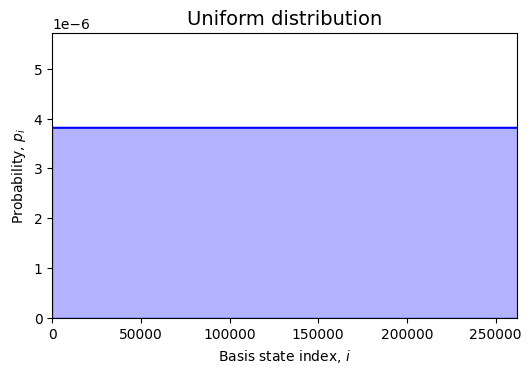

In [15]:
# Uniform distribution

p_uniform = np.ones(d) / d

plt.figure(figsize=(6, 3.7))
plt.step(indices, p_uniform, where='mid', color='blue')
plt.fill_between(indices, 0, p_uniform, step='mid',
                 color='blue', alpha=.3)
plt.title('Uniform distribution', fontsize=14)
plt.xlabel('Basis state index, $i$')
plt.ylabel('Probability, $p_i$')
plt.xlim(0, d)
plt.ylim(0, 1.5/d)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useMathText=True)
plt.show()

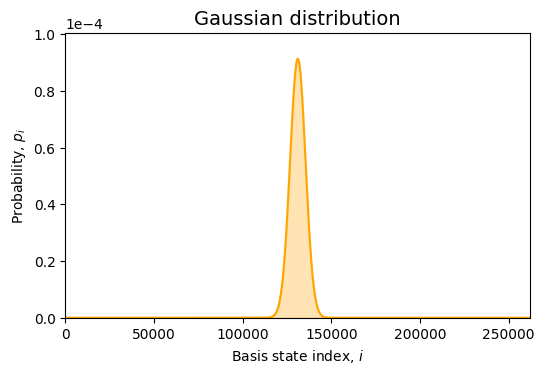

In [16]:
# Gaussian distribution

x = np.linspace(-3, 3, d)
p_normal = np.exp(-x**2/(2*sigma**2))
p_normal /= p_normal.sum()

plt.figure(figsize=(6, 3.7))
plt.plot(indices, p_normal, color='orange', lw=1.5)
plt.fill_between(indices, p_normal, color='orange', alpha=.3)
plt.title('Gaussian distribution', fontsize=14)
plt.xlabel('Basis state index, $i$')
plt.ylabel('Probability, $p_i$')
plt.xlim(0, d)
plt.ylim(0, 1.1*p_normal.max())
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useMathText=True)
plt.show()

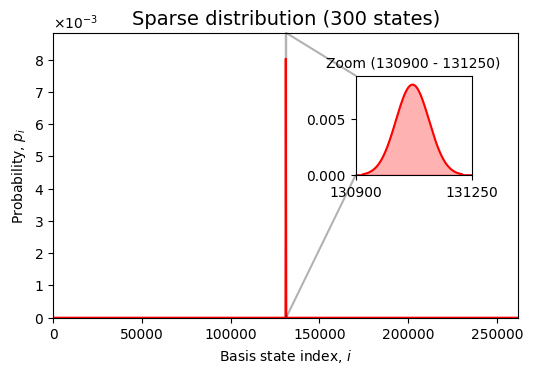

In [21]:
# Sparse Gaussian distribution
n_sparse_var = 300
x_block = np.linspace(-3, 3, n_sparse_var)
p_block = np.exp(-x_block**2/2)
p_block /= p_block.sum()

centre = d // 2

p_sparse_var = np.zeros(d)
start = centre - n_sparse_var // 2
end_d = start + n_sparse_var
p_sparse_var[start:end_d] = p_block

fig, ax = plt.subplots(figsize=(6, 3.7))

zoom_xlim = (130900, 131250)
zoom_ylim = (0, 1.1*p_sparse_var.max())

ax.plot(indices, p_sparse_var, color='red', lw=1.5)
ax.fill_between(indices, p_sparse_var, color='red', alpha=.3)

ax.set_title('Sparse distribution (300 states)', fontsize=14)
ax.set_xlabel('Basis state index, $i$')
ax.set_ylabel('Probability, $p_i$')
ax.set_xlim(0, d)
ax.set_ylim(zoom_ylim)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useMathText=True)

ax.add_patch(Rectangle(
    (zoom_xlim[0], 0),
    zoom_xlim[1] - zoom_xlim[0],
    zoom_ylim[1],
    lw=1, edgecolor='black', facecolor='none', alpha=.3))

axins = ax.inset_axes([0.65, 0.5, 0.25, 0.35])
axins.plot(indices, p_sparse_var, color='red', lw=1.5)
axins.fill_between(indices, p_sparse_var, color='red', alpha=.3)
axins.set_xlim(zoom_xlim)
axins.set_ylim(zoom_ylim)
axins.set_title('Zoom (130900 - 131250)', fontsize=10)
axins.set_xticks(zoom_xlim)

for y in zoom_ylim:
    fig.add_artist(ConnectionPatch(
        xyA=(zoom_xlim[1], y),
        xyB=(zoom_xlim[0], y),
        coordsA='data', coordsB='data',
        axesA=ax, axesB=axins,
        color='black', lw=1.5, alpha=.3))
plt.show()

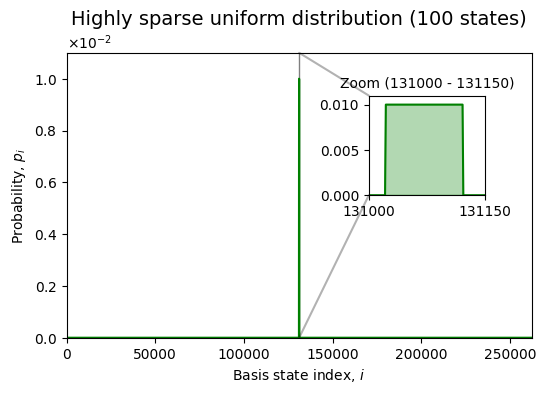

In [20]:
# Highly sparse uniform distribution

n_sparse_flat = 100
p_sparse_flat = np.zeros(d)

start = centre - n_sparse_flat // 2
end_d = start + n_sparse_flat

p_sparse_flat[start:end_d] = 1 / n_sparse_flat

fig, ax = plt.subplots(figsize=(6, 3.7))

zoom_xlim = (131000, 131150)
zoom_ylim = (0, 1.1*p_sparse_flat.max())

ax.plot(indices, p_sparse_flat, color='green', lw=1.5)
ax.fill_between(indices, p_sparse_flat, color='green', alpha=.3)

ax.set_title('Highly sparse uniform distribution (100 states)', fontsize=14)
ax.set_xlabel('Basis state index, $i$')
ax.set_ylabel('Probability, $p_i$')
ax.set_xlim(0, d)
ax.set_ylim(zoom_ylim)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useMathText=True)

ax.add_patch(Rectangle(
    (zoom_xlim[0], 0),
    zoom_xlim[1] - zoom_xlim[0],
    zoom_ylim[1],
    lw=1, edgecolor='black', facecolor='none', alpha=.5))

axins = ax.inset_axes([0.65, 0.5, 0.25, 0.35])
axins.plot(indices, p_sparse_flat, color='green', lw=1.5)
axins.fill_between(indices, p_sparse_flat, color='green', alpha=.3)
axins.set_xlim(zoom_xlim)
axins.set_ylim(zoom_ylim)
axins.set_title('Zoom (131000 - 131150)', fontsize=10)
axins.set_xticks(zoom_xlim)

for y in zoom_ylim:
    fig.add_artist(ConnectionPatch(
        xyA=(zoom_xlim[1], y),
        xyB=(zoom_xlim[0], y),
        coordsA='data', coordsB='data',
        axesA=ax, axesB=axins,
        color='black', lw=1.5, alpha=.3))

plt.show()



The first stage of this protocol consists of sequentially performing projective measurements in the computational basis. In this experiment, the maximum number of measurements is limited to a budget of $M_{\max} = 15,000$ shots. Based on these measurements, the specific basis states observed, along with their respective occurrence frequencies, are registered. The evolution of the number of distinct basis states identified as a function of the number of measurements for each of the aforementioned probability distributions is illustrated in the following figure:

In [27]:
# Maximum number of measurements
M_max = 15000

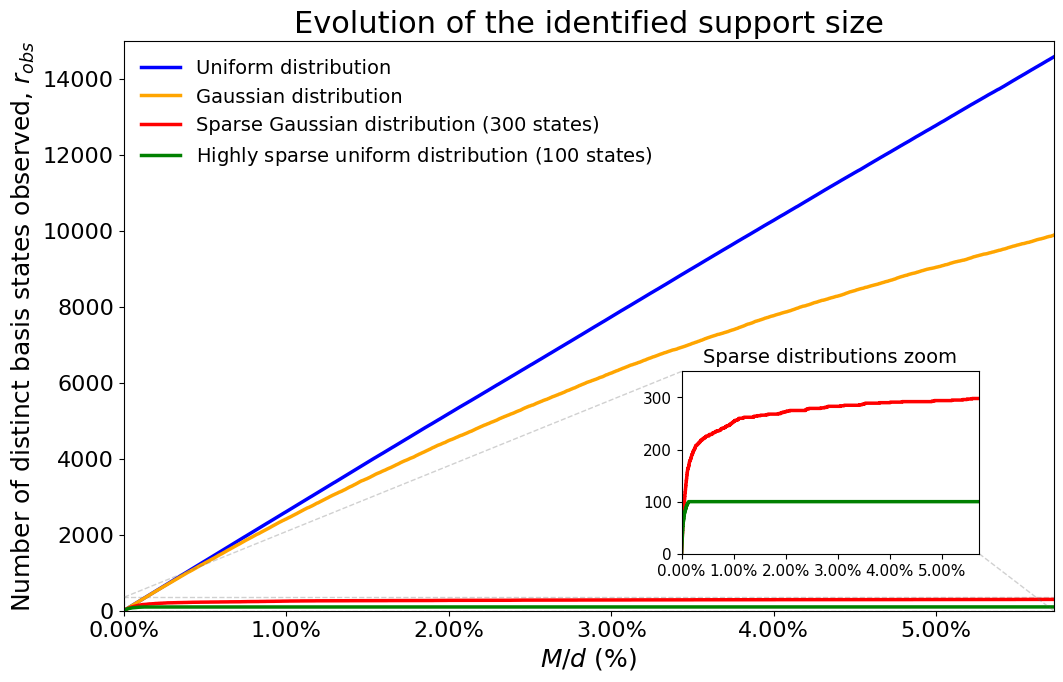

In [28]:
def accumulation_sim(p, shots):
    """
    Simulates the sequential growth of the observed support size (r_obs) over a sequence of computational-basis measurements.

    Parameters:
    -----------
    p : ndarray
        Underlying probability distribution across the d basis states.
    shots : int
        Total number of projective measurements to perform.

    Returns:
    --------
    ndarray
        Cumulative count of distinct basis states observed up to each measurement step.
    """
    samples = np.random.choice(d, size=shots, p=p)
    _, first_time = np.unique(samples, return_index=True)
    new_indices = np.zeros(shots)
    new_indices[first_time] = 1
    return np.cumsum(new_indices)

acum_uniform = accumulation_sim(p_uniform, M_max)
acum_normal = accumulation_sim(p_normal, M_max)
acum_sparse_var = accumulation_sim(p_sparse_var, M_max)
acum_sparse_flat = accumulation_sim(p_sparse_flat, M_max)

x_measurements = np.arange(1, M_max + 1)
x_percentage = (x_measurements / d) * 100

fig, ax = plt.subplots(figsize=(12, 7.4))

ax.plot(x_percentage, acum_uniform,
        label='Uniform distribution', color='blue', lw=2.5)
ax.plot(x_percentage, acum_normal,
        label='Gaussian distribution', color='orange', lw=2.5)
ax.plot(x_percentage, acum_sparse_var,
        label='Sparse Gaussian distribution (300 states)', color='red', lw=2.5)
ax.plot(x_percentage, acum_sparse_flat,
        label='Highly sparse uniform distribution ($100$ states)', color='green', lw=2.5)

ax.set_title('Evolution of the identified support size', fontsize=22)
ax.set_xlabel(r'$M/d \ (\%)$', fontsize=18)
ax.set_ylabel(r'Number of distinct basis states observed, $r_{obs}$', fontsize=18)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlim(0, M_max / d * 100)
ax.set_ylim(0, M_max)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

# Zoom
ax_inset = inset_axes(
    ax, width="100%", height="100%",
    bbox_to_anchor=(.6, .1, .32, .32),
    bbox_transform=ax.transAxes,
    loc='lower left', borderpad=0
)

ax_inset.plot(x_percentage, acum_sparse_var, color='red', lw=2.5)
ax_inset.plot(x_percentage, acum_sparse_flat, color='green', lw=2.5)

ax.legend(
    loc='upper left',
    fontsize=14,
    frameon=False
)

ax_inset.set_title('Sparse distributions zoom', fontsize=14, pad=6)
ax_inset.set_xlim(0, M_max / d * 100)
ax_inset.set_ylim(0, 350)
ax_inset.tick_params(axis='both', labelsize=11)
ax_inset.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

mark_inset(
    ax, ax_inset,
    loc1=2, loc2=4,
    fc="none", ec="0.4",
    linestyle="--", alpha=.3
)

plt.show()

After each additional computational-basis measurement $M$, the true unobserved missing mass $M_0$ (corresponding to the cumulative probability mass of the unobserved states) is bounded using the Good–Turing framework. First, it is necessary to compute the empirical Good–Turing missing-mass estimator based on the number of states observed exactly once ($n_1$):
$$ G_{0} = \frac{n_{1}}{M}$$
The following figure shows the evolution of the number of states observed exactly once ($n_{1}$) as a function of the number of measurements performed:


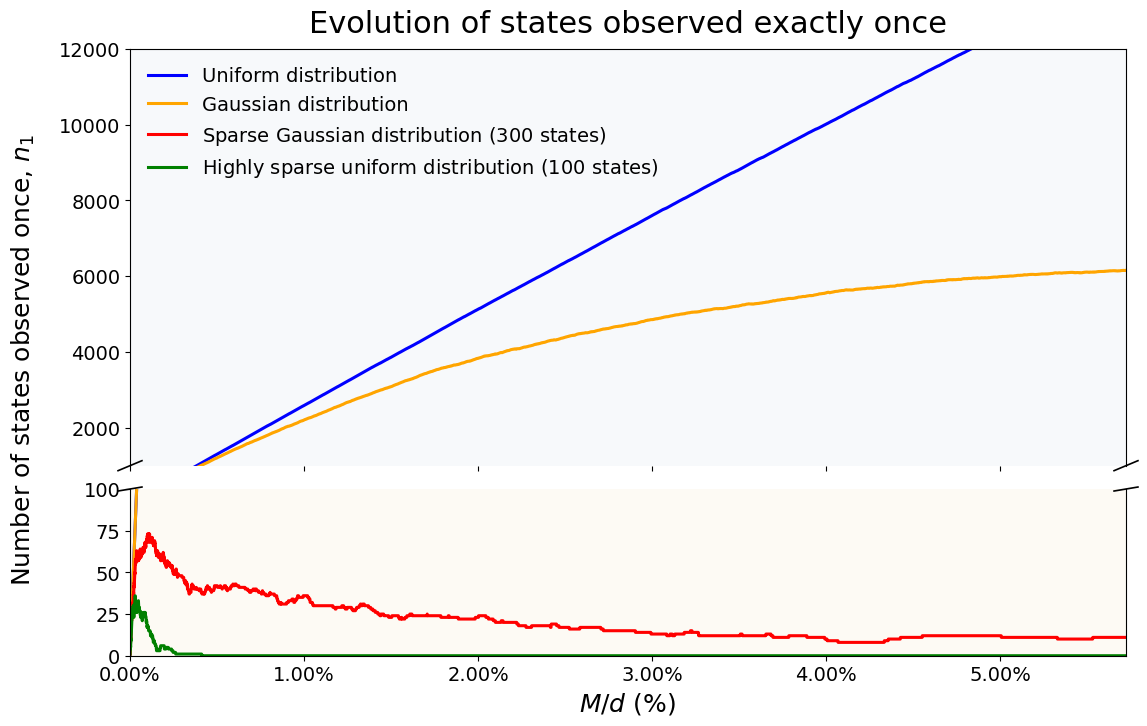

In [29]:
def singletons_sim(p, shots):
    samples = np.random.choice(d, size=shots, p=p)
    counts = np.zeros(d, dtype=int)
    singletons = np.zeros(shots, dtype=int)

    n_singletons = 0

    for t, state in enumerate(samples):
        if counts[state] == 0:
            n_singletons += 1
        elif counts[state] == 1:
            n_singletons -= 1
        counts[state] += 1
        singletons[t] = n_singletons
    return singletons

singletons_uniform = singletons_sim(p_uniform, M_max)
singletons_normal = singletons_sim(p_normal, M_max)
singletons_sparse_flat = singletons_sim(p_sparse_flat, M_max)
singletons_sparse_var = singletons_sim(p_sparse_var, M_max)

# Broken axis
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(12, 7.4),
    gridspec_kw={'height_ratios': [2.5, 1], 'hspace': 0.08}
)

ax_top.set_facecolor('#f7f9fb')
ax_bot.set_facecolor('#fdfaf4')

for ax in (ax_top, ax_bot):
    ax.plot(x_percentage, singletons_uniform,
            label='Uniform distribution', color='blue', lw=2.2)
    ax.plot(x_percentage, singletons_normal,
            label='Gaussian distribution', color='orange', lw=2.2)
    ax.plot(x_percentage, singletons_sparse_var,
            label='Sparse Gaussian distribution ($300$ states)',
            color='red', lw=2.2)
    ax.plot(x_percentage, singletons_sparse_flat,
            label='Highly sparse uniform distribution ($100$ states)',
            color='green', lw=2.2)
    ax.tick_params(axis='both', labelsize=14)

ax_top.set_ylim(1000, 12000)
ax_bot.set_ylim(0, 100)
ax_bot.set_xlim(0, M_max / d * 100)

ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)

ax_top.tick_params(labeltop=False, top=False)
ax_bot.xaxis.set_major_formatter(
    mtick.PercentFormatter(decimals=2)
)

# Diagonal marks
d_len = .012
kwargs = dict(
    transform=ax_top.transAxes,
    color='k', clip_on=False, lw=1.2
)

ax_top.plot((-d_len, d_len), (-d_len, d_len), **kwargs)
ax_top.plot((1-d_len, 1+d_len), (-d_len, d_len), **kwargs)

kwargs.update(transform=ax_bot.transAxes)

ax_bot.plot(
    (-d_len, d_len), (1-d_len, 1+d_len), **kwargs
)
ax_bot.plot(
    (1-d_len, 1+d_len), (1-d_len, 1+d_len), **kwargs
)


ax_top.set_title('Evolution of states observed exactly once',
                 fontsize=22, pad=12
                 )

ax_bot.set_xlabel(r'$M/d \ (\%)$', fontsize=18)

fig.text(0.02, 0.5,
         r'Number of states observed once, $n_{1}$',
         va='center', rotation='vertical', fontsize=18
)

ax_top.legend(fontsize=14,
              loc='upper left',
              frameon=False
              )

plt.subplots_adjust(
    left=.12,
    right=.95,
    top=.92,
    bottom=.1
)

plt.show()


From the count of basis states observed exactly once ($n_1$), we compute the evolution of the empirical Good–Turing missing-mass estimator. This estimator provides an empirical estimate of the probability mass belonging to the unobserved tail of the distribution. For sparse distributions, as repeated observations accumulate across the finite support, $G_{0}$ rapidly decays towards zero, confirming that only a negligible fraction of the probability mass remains unseen. In contrast, dense distributions continuously yield new outcomes, causing $G_0$ to remain close to one. The following shows the evolution of the empirical Good–Turing estimate.

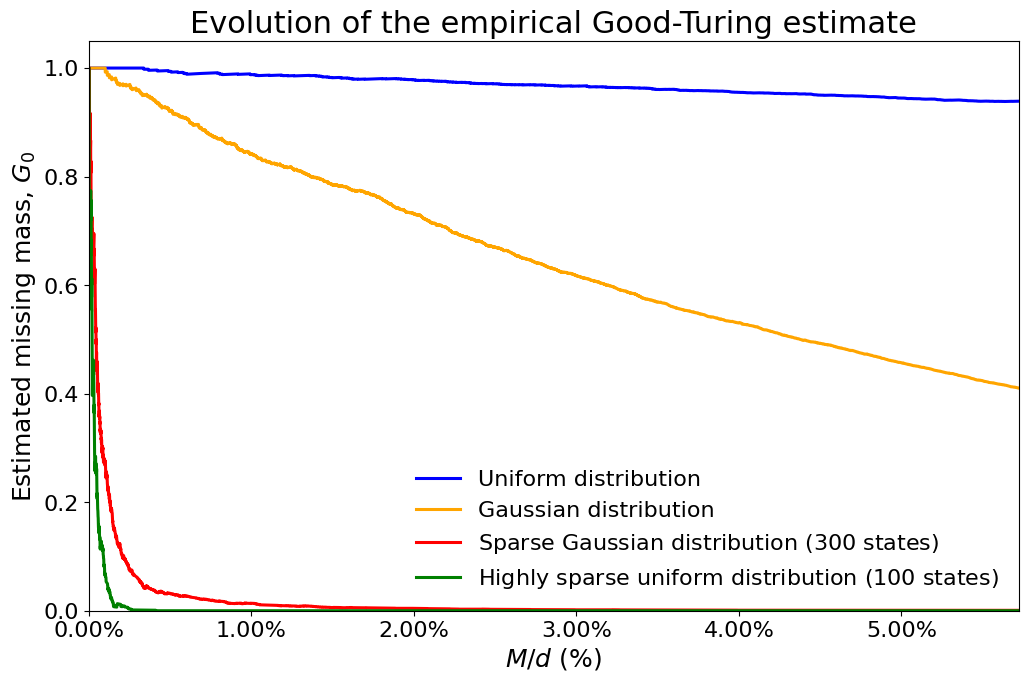

In [31]:
# GT estimation
gt_uniform = singletons_uniform / x_measurements
gt_normal = singletons_normal / x_measurements
gt_sparse_flat = singletons_sparse_flat / x_measurements
gt_sparse_var = singletons_sparse_var / x_measurements


fig, ax = plt.subplots(figsize=(12, 7.4))

ax.plot(x_percentage, gt_uniform,
        label='Uniform distribution', color='blue', lw=2.2)
ax.plot(x_percentage, gt_normal,
        label='Gaussian distribution', color='orange', lw=2.2)
ax.plot(x_percentage, gt_sparse_var,
        label='Sparse Gaussian distribution ($300$ states)',
        color='red', lw=2.2)
ax.plot(x_percentage, gt_sparse_flat,
        label='Highly sparse uniform distribution ($100$ states)',
        color='green', lw=2.2)

ax.set_title('Evolution of the empirical Good-Turing estimate', fontsize=22)
ax.set_xlabel(r'$M/d \ (\%)$', fontsize=18)
ax.set_ylabel('Estimated missing mass, $G_{0}$', fontsize=18)

ax.legend(fontsize=16, loc='lower right', frameon=False)
ax.tick_params(axis='both', labelsize=16)

ax.set_xlim(0, M_max / d * 100)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

plt.show()